<img src='../OUTILS/bandeau_MF.png' align='right' width='100%'/>

<div class="alert alert-info alert-success">
<h3>Élaboration d'un produit RGB à partir de NetCDF - FCI /MTG </h3></div>

## <a id='TOC-TOP'></a>Contenus

<div class="alert alert-block alert-warning">
    
<b>PREREQUIS </b>
    
Ce Notebook ne nécessite pas de prérequis 

</div>
<hr>

<div class="alert alert-info" role="alert">

## <a id='section1'></a>1.Tout d'abord, il faut procéder à l'importation des librairies nécessaires.

</div>

In [ ]:
from PIL import Image
from IPython.display import display, HTML
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import os
import subprocess
import sys
import os
from osgeo import gdal
from PIL import Image
os.environ['PATH'] = f"/opt/conda/env_MF_teledetection/bin:{os.environ['PATH']}" 
os.environ['PATH'] = f"~/.conda/envs/env_MF_teledetection/bin:{os.environ['PATH']}"
os.environ['GDAL_DATA'] = '/opt/conda/env_MF_teledetection/share/gdal'
os.environ['PROJ_LIB'] = '/opt/conda/env_MF_teledetection/share/proj'

### Se déplacer dans le répertoire contenant les fichiers et répertoires, puis définition des chemins des données sources, des futurs résultats, création de répertoire

In [ ]:
!cd ~/MF_DATA_MANIPULATION                          # commande "cd" pour *change directory*, "~" pour votre home

download_dir = os.path.join(os.getcwd(), "RESULTS") # création du répertoires de résultats "RESULTS" si nécessaire
os.makedirs(download_dir, exist_ok=True)            # création du répertoires de résultats "RESULTS" si nécessaire

input = '/stockage/DATA/NETCDF_multicanaux/Mmultic2kmNC4_mtgi1_202509291400.nc' # Définition du fichier contenant les données sources
output = 'RESULTS'                                                              # Définition du répertoires de résultats

### Parcourir les métadonnées des fichiers NetCDF (données sources) avec la *commande gdalinfo* suivi du chemin indiquant où se trouvent les données
Rmq : un "!" est parfois nécessaires dans les cellules des Jupyter Notebook afin d'excuter certaines commmandes

In [ ]:
!gdalinfo /stockage/DATA/NETCDF_multicanaux/Mmultic2kmNC4_mtgi1_202509291400.nc

In [ ]:
!gdalinfo -mm NETCDF:"/stockage/DATA/NETCDF_multicanaux/Mmultic2kmNC4_mtgi1_202509291400.nc":VIS006 #Parcourir les métadonnées de la bande VIS0.64

### Extraction d'une bande d'un netcdf en fichier géoréférencé "tif", et conversion en "png", puis affichage.

In [ ]:
!gdal_translate -q -ot byte -scale 0 10000 0 255 NETCDF:"$input":VIS006 {output}/VIS0.64.tif       # Extraction de la bande VIS0.64 (VIS006)
!gdalwarp -q -overwrite -ts 500 500 {output}/VIS0.64.tif {output}/VIS0.64.jpg                      # Création d'un jpg de seulement 500 pixels par 500 pixels pour affichage rapide dans le JNB (Jupyter NoteBook)
im0 = Image.open(output + '/VIS0.64.jpg')                                                       #affichage de l'image
display(im0)

<div class="alert alert-info" role="alert">

## <a id='section2'></a>2.Extraction des données dans le NetCDF, afin de réaliser un produit composite Cloud 


</div>


La recette de la RGB cloud type est la suivante :

<img src='../OUTILS/cloudtype_tableau.png' align='left' width='60%'/>

Red: NIR1.38, range 0 to 10 %, Gamma = 1.5 </br>
Green: VIS0.67, Range 0 to 80 %, Gamma = 0.75 </br>
Blue: VIS1.61, range 0 to 80 %, Gamma = 1 </br>


### Extraction des données des trois longueurs d'ondes nécessaires aux calculs des différences :
**NIR1.38 pour la bande rouge, suivant la "recette" officielle** </br>
Option : -ot byte: spécifie le type de données de sortie en 8bits. Ici limitation à une plage de 0 à 255 </br>
Seules valeurs 0 à 10 % seront utilisées pour cette bande, on parle de changement de "dynamique". Le maximum étant 7065, la valeur 10% est 706 (voir commande gdalinfo ci-dessous)</br>
0 706 0 255 recalibre les valeurs de pixels. Les valeurs d'entrée entre 0 et 706 seront linéairement mises à l'échelle pour être comprises entre 0 et 255 (8bits) </br>


In [ ]:
!gdalinfo -mm NETCDF:"/stockage/DATA/NETCDF_multicanaux/Mmultic2kmNC4_mtgi1_202509291400.nc":IR_013 |grep "Computed Min/Max" #Parcourir les métadonnées de la bande NIR1.38 et filtrer l'information sur les Min/Max avec al commande grep

In [ ]:
!gdal_translate -q -ot byte -scale 0 706 0 255 NETCDF:"$input":IR_013 {output}/NIR1.38_scale.tif         # Extraction et modification de la dynamique
!gdalwarp -q -overwrite -ts 500 500 {output}/NIR1.38_scale.tif {output}/NIR1.38_scale.jpg                # Création d'un fichier jpg de seulement 500 pixels pour affichage rapide
im2 = Image.open(output + '/NIR1.38_scale.jpg')                                                          # Visualisation du résultat
display(im2)

### Exemples de modification de la dynamique pour une image type (autre situation)

<img src='../OUTILS/ir_013_dynamiques.jpg' align='left' width='90%'/>

<img src='../OUTILS/ir_013_dynamiques2.jpg' align='left' width='35%'/>

<img src='../OUTILS/ir_013_dynamiques3.jpg' align='left' width='50%'/>

Extraction des données VIS006 pour la bande verte.
Les valeurs 0 et 80 % 
Extraction des données NIR1.61 pour la bande bleue.Les valeurs 0 et 80 % 



In [ ]:
!gdal_translate -ot byte -scale 0 8000 0 255 NETCDF:"$input":VIS006 {output}/VIS0.64_scale.tif # Extraction de la bande avec gdal_translate et modifcation de la dynamique
!gdal_translate -ot byte -scale 0 8000 0 255 NETCDF:"$input":IR_016 {output}/NIR1.61_scale.tif # Extraction de la bande avec gdal_translate et modifcation de la dynamique

### Calcul de la correction gamma avec gdal_calc.py :

Pour rappel la formule de la correction gamme est :

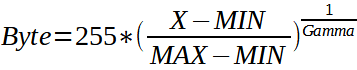

Le gamma en imagerie fait référence à une correction non linéaire de la luminosité, en particulier la façon dont les tons intermédiaires (gris ou couleurs moyennes) sont rendus.  </br>
gamma <1 l'image devient plus sombre, ce qui peut donner plus de contraste </br>
gamma >1 l'image devient plus clair, ce qui peut révéler plus de détails </br>
(Note : imagemagick permet de faire une correction gamma mais n'est pas compatible avec Windows)

La première étape consiste à extraire les valeurs min et max de l'image, qui serviront au calcul du gamma

In [ ]:
file_in = 'RESULTS/NIR1.38_scale.tif'
imgpil = Image.open(file_in)  
img = np.array(imgpil)
max = np.max(img)
min = np.min(img)

### Ensuite on calcule et on applique la correction gamma pour une valeur de 1.5 pour le NIR1.38 :

In [ ]:
gamma= 1.5      # valeur du gamma
!gdal_calc.py --quiet --NoDataValue 0 --overwrite -A {file_in} --calc="numpy.maximum(A*0.,{max}*((A-{min}.)/({max}-{min}))**(1/{gamma}))" --outfile {output}/NIR1.38_scale_gamma.tif      #application du gamma
!gdalwarp -q -overwrite -ts 3000 3000 {output}/NIR1.38_scale_gamma.tif {output}/NIR1.38_scale_gamma_HD.jpg  # Création d'une image
!gdalwarp -q  -overwrite -ts 500 500 {output}/NIR1.38_scale_gamma.tif {output}/NIR1.38_scale_gamma.jpg       # Création d'une seconde image plus légère pour affichage
im3 = Image.open(output + '/NIR1.38_scale_gamma.jpg')                                                    # Affichage de l'image
display(im3)

### Canal VIS0.64

Extraire les valeurs min et max de l'image, qui serviront au calcul du gamma

In [ ]:
file_in = 'RESULTS/VIS0.64_scale.tif'
imgpil = Image.open(file_in)  
img = np.array(imgpil)
max = np.max(img)
min = np.min(img)

In [ ]:
gamma= 0.75   # valeur du gamma
!gdal_calc.py --quiet --NoDataValue 0 --overwrite -A {file_in} --calc="numpy.maximum(A*0.,{max}*((A-{min}.)/({max}-{min}))**(1/{gamma}))" --outfile {output}/VIS0.64_scale_gamma.tif  # application du gamma
!gdalwarp -overwrite -ts 500 500 {output}/VIS0.64_scale_gamma.tif {output}/VIS0.64_scale_gamma.jpg #creation d'une image jpg
im4 = Image.open(output + '/VIS0.64_scale_gamma.jpg')   #affichage
display(im4)

In [ ]:
### Canal NIR1.61

In [ ]:
file_in = 'RESULTS/NIR1.61_scale.tif'
imgpil = Image.open(file_in)  
img = np.array(imgpil)
max = np.max(img)
min = np.min(img)

In [ ]:
gamma= 1            # valeur du gamma
!gdal_calc.py --quiet --NoDataValue 0 --overwrite -A {file_in} --calc="numpy.maximum(A*0.,{max}*((A-{min}.)/({max}-{min}))**(1/{gamma}))" --outfile {output}/NIR1.61_scale_gamma.tif       # application du gamma
!gdalwarp -overwrite -ts 500 500 {output}/NIR1.61_scale_gamma.tif {output}/NIR1.61_scale_gamma.jpg    #creation d'un fichier jpg
im5 = Image.open(output + '/NIR1.61_scale_gamma.jpg')          #affichage de l'image
display(im5)

<div class="alert alert-info" role="alert">

## <a id='section3'></a>3.Fabrication de la RGB

</div>


### Fusion des couches

In [ ]:
!gdal_merge.py -separate {output}/NIR1.38_scale_gamma.tif {output}/VIS0.64_scale_gamma.tif {output}/NIR1.61_scale_gamma.tif -o {output}/RGB_cloudtype.tif    # fusion des 3 couches
!convert -resize 3000 {output}/RGB_cloudtype.tif {output}/RGB_cloudtype_min.jpg  > /dev/null 2>&1   # Création d'une image
!convert -resize 500 {output}/RGB_cloudtype.tif {output}/RGB_cloudtype_min.jpg  > /dev/null 2>&1   # Création d'une image légère
im6 = Image.open(output + '/RGB_cloudtype_min.jpg', 'r')      # affichage du résultat
display(im6)

<div class="alert alert-info" role="alert">

## <a id='section4'></a>4.Découpes et reprojections

</div>

## WGS 84 (World Geodetic System 1984): EPSG: 4326 Un système de coordonnées géographiques utilisé pour le GPS et d'autres applications géospatiales. 

### Définition de la zone de découpe : coordonnées des bords de domaine

In [ ]:
nord=40
sud=0
ouest=-23
est=8

In [ ]:
!gdalwarp -q -t_srs "EPSG:4326" -te {ouest} {sud} {est} {nord} -overwrite {output}/RGB_cloudtype.tif {output}/RGB_cloudtype_zoom.tif #W S E N     #découpe avec la commande gdalwarp 
!convert -resize 500 {output}/RGB_cloudtype_zoom.tif {output}/RGB_cloudtype_zoom_min.jpg  > /dev/null 2>&1      # Création d'une image légère
im7 = Image.open(output + '/RGB_cloudtype_zoom_min.jpg', 'r')    #affichage de l'image
display(im7)

## Utilisation de la projection orthographique

In [ ]:
### Définition du centre de la zone de découpe

In [ ]:
latitude=45
longitude=1
taille_domaine="-1720000 -990000 1720000 990000" # (mètres)

In [ ]:
!gdalwarp -q -overwrite  -t_srs "+proj=ortho lat_0={latitude} lon_0={longitude}" -te {taille_domaine} {output}/RGB_cloudtype.tif {output}/RGB_cloudtype_zoom_ortho.tif  #découpe
!gdal_rasterize -b 1 -burn 250 -b 2 -burn 250 -b 3 -burn 250 -l world-administrative-boundaries OUTILS/boundary/world-administrative-boundaries.shp {output}/RGB_cloudtype_zoom_ortho.tif >/dev/null 2>&1   # ajout frontière blanche   
!convert -resize 800 {output}/RGB_cloudtype_zoom_ortho.tif {output}/RGB_cloudtype_zoom_ortho_min.jpg >/dev/null 2>&1  #Création image légère
im8 = Image.open(output + '/RGB_cloudtype_zoom_ortho_min.jpg', 'r') # affichage
display(im8)

## Utilisation de la projection Mercator (3857)

Notez que si vous utilisez la projection Mercator, les coordonnées -te doivent être exprimées en mètres, et non plus en degrés de latitude et de longitude. 
Vous devrez donc convertir les coordonnées en mètres pour utiliser cette projection.

In [ ]:
nord=40
sud=0
ouest=-23
est=8

In [ ]:
#Conversion du point en bas à gauche (x,y)
!echo {ouest} {sud} | cs2cs +init=epsg:4326 +to +init=epsg:3857
#Conversion du point en haut à droite (x,y)
!echo {est} {nord} | cs2cs +init=epsg:4326 +to +init=epsg:3857

In [ ]:
!echo {coord}

In [ ]:
!gdalwarp -t_srs "EPSG:3857" -te -2560348.29 0 890555.93 4865942.28 -overwrite {output}/RGB_cloudtype_zoom.tif {output}/RGB_cloudtype_zoom_3857.tif # decoupe
!convert -resize 500 {output}/RGB_cloudtype_zoom_3857.tif {output}/RGB_cloudtype_zoom_3857_min.jpg  >/dev/null 2>&1  #creation image légère
im9 = Image.open(output + '/RGB_cloudtype_zoom_3857_min.jpg', 'r')   #affichage de l'image
display(im9)

Nettoyage

Un oeil sur l'Ouragan Hamilton (en toute limite de disque, au nord de la République dominicaine)

In [ ]:
!gdalwarp -q -t_srs "EPSG:4326" -te -75 16 -53 34 -overwrite {output}/RGB_cloudtype.tif {output}/RGB_cloudtype_zoom_ouragan.tif #(coord W S E N)
!convert -resize 600 {output}/RGB_cloudtype_zoom_ouragan.tif {output}/RGB_cloudtype_zoom_ouragan.jpg  >/dev/null 2>&1 
im10 = Image.open(output + '/RGB_cloudtype_zoom_ouragan.jpg', 'r')
display(im10)

In [ ]:
!rm {output}/*tif {output}/*xml